In [1]:
from IPython.display import IFrame
IFrame("https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones", 900,500)

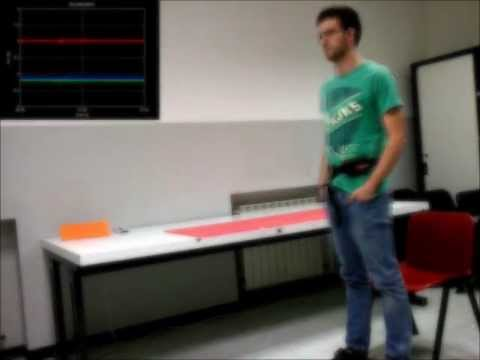

In [2]:
from IPython.display import YouTubeVideo
YouTubeVideo('XOEN9W05_4A')

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
import keras_tuner as kt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# ฟังก์ชันเพื่อโหลด Inertial Signals
def load_signals(subset='train'):
    signals = [
        'body_acc_x',
        'body_acc_y',
        'body_acc_z',
        'body_gyro_x',
        'body_gyro_y',
        'body_gyro_z',
        'total_acc_x',
        'total_acc_y',
        'total_acc_z'
    ]
    data = []
    for signal in signals:
        filename = f'UCI_HAR_Dataset/{subset}/Inertial Signals/{signal}_{subset}.txt'
        df = pd.read_csv(filename, sep=r'\s+', header=None)
        data.append(df.values)
    # Stack signals to form (samples, time_steps, features)
    X = np.stack(data, axis=2)  # (samples, 128, 9)
    return X

# โหลด train และ test signals
X_train = load_signals('train')  # shape (7352, 128, 9)
y_train = pd.read_csv('UCI_HAR_Dataset/train/y_train.txt', header=None)
X_test = load_signals('test')    # shape (2947, 128, 9)
y_test = pd.read_csv('UCI_HAR_Dataset/test/y_test.txt', header=None)

# รวมข้อมูล train และ test
X = np.concatenate((X_train, X_test), axis=0)  # shape (10299, 128, 9)
y = pd.concat([y_train, y_test], axis=0).values.ravel() - 1  # แปลง labels จาก 1-6 เป็น 0-5
y = to_categorical(y)  # แปลงเป็น categorical

# ตรวจสอบขนาดของ X ก่อน
print(f"ขนาดของ X ก่อน reshape: {X.shape}")  # ควรเป็น (10299, 128, 9)

# แบ่งข้อมูลเป็น train และ validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# แสดงตัวอย่างข้อมูล
print("ตัวอย่าง X_train (5 แถว):")
print(X_train[:5])

print("\nตัวอย่าง y_train (5 แถว):")
print(y_train[:5])

/tmp/ipykernel_17959/473399781.py:30: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, delim_whitespace=True, header=None)
/tmp/ipykernel_17959/473399781.py:30: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, delim_whitespace=True, header=None)
/tmp/ipykernel_17959/473399781.py:30: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, delim_whitespace=True, header=None)
/tmp/ipykernel_17959/473399781.py:30: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, delim_whitespace=True, header=None)
/tmp/ipykernel_17959

ขนาดของ X ก่อน reshape: (10299, 128, 9)
ตัวอย่าง X_train (5 แถว):
[[[ 6.494217e-01  4.468635e-02  1.391400e-01 ...  1.659395e+00
   -1.852017e-01  1.233219e-01]
  [ 4.152194e-01 -6.797595e-02  1.433019e-01 ...  1.424556e+00
   -2.975868e-01  1.264412e-01]
  [ 1.408442e-01 -1.173335e-01  9.908113e-02 ...  1.149636e+00
   -3.465989e-01  8.127650e-02]
  ...
  [-6.028215e-02 -1.813258e-01  7.403437e-02 ...  9.336894e-01
   -4.120440e-01  2.675662e-02]
  [-2.099874e-01 -1.376815e-01  3.042477e-02 ...  7.835797e-01
   -3.687784e-01 -1.705183e-02]
  [-5.244817e-02 -1.507233e-01 -1.665463e-03 ...  9.407965e-01
   -3.821745e-01 -4.922425e-02]]

 [[ 2.681245e-01  4.611424e-01 -2.034126e-01 ...  1.266314e+00
    2.338528e-01 -2.584464e-01]
  [-3.735770e-02  4.188068e-01 -1.629399e-01 ...  9.608748e-01
    1.914446e-01 -2.183439e-01]
  [-1.934070e-01  1.932368e-01 -5.981280e-02 ...  8.049414e-01
   -3.418091e-02 -1.156210e-01]
  ...
  [-2.465133e-01 -2.542610e-01  1.809058e-01 ...  7.454686e-01
  

In [4]:
# สร้างโมเดล CNN-LSTM
def build_cnn_lstm_model(hp):
    model = tf.keras.models.Sequential()
    model.add(tf.keras.layers.Conv1D(filters=hp.Int('filters', 32, 128, step=32), kernel_size=3, activation='relu', input_shape=(128, 9)))
    model.add(tf.keras.layers.MaxPooling1D(pool_size=2))
    model.add(tf.keras.layers.Dropout(0.5))
    model.add(tf.keras.layers.LSTM(hp.Int('units', 32, 128, step=32)))
    model.add(tf.keras.layers.Dense(6, activation='softmax'))  # สำหรับ 6 classes

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# ใช้ Random Search ผ่าน KerasTuner แทน Grid Search
tuner_cnn_lstm = kt.RandomSearch(
    build_cnn_lstm_model,
    objective='val_accuracy',
    max_trials=5,  # กำหนดจำนวน trials (จำนวนการทดสอบที่แตกต่างกัน)
    directory='random_search', 
    project_name='cnn_lstm_har'
)

# รันการค้นหา
tuner_cnn_lstm.search(X_train, y_train, epochs=5, validation_data=(X_val, y_val))

# แสดงไฮเปอร์พารามิเตอร์ที่ดีที่สุด
best_hps_cnn_lstm = tuner_cnn_lstm.get_best_hyperparameters(num_trials=1)[0]

print(f'Best number of filters: {best_hps_cnn_lstm.get("filters")}')
print(f'Best number of LSTM units: {best_hps_cnn_lstm.get("units")}')

# สร้างและฝึกโมเดลที่ดีที่สุดด้วยไฮเปอร์พารามิเตอร์ที่ดีที่สุด
best_cnn_lstm_model = tuner_cnn_lstm.hypermodel.build(best_hps_cnn_lstm)
best_cnn_lstm_model.fit(X_train, y_train, epochs=5, validation_data=(X_val, y_val))

Trial 5 Complete [00h 03m 23s]
val_accuracy: 0.9427184462547302

Best val_accuracy So Far: 0.9456310868263245
Total elapsed time: 00h 13m 44s
Best number of filters: 96
Best number of LSTM units: 32
Epoch 1/5
258/258 ━━━━━━━━━━━━━━━━━━━━ 23s 72ms/step - accuracy: 0.6685 - loss: 0.8170 - val_accuracy: 0.8039 - val_loss: 0.5172
Epoch 2/5
258/258 ━━━━━━━━━━━━━━━━━━━━ 19s 64ms/step - accuracy: 0.8489 - loss: 0.4166 - val_accuracy: 0.8879 - val_loss: 0.2978
Epoch 3/5
258/258 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.9107 - loss: 0.2535 - val_accuracy: 0.9306 - val_loss: 0.1987
Epoch 4/5
258/258 ━━━━━━━━━━━━━━━━━━━━ 19s 72ms/step - accuracy: 0.9229 - loss: 0.2034 - val_accuracy: 0.9141 - val_loss: 0.2022
Epoch 5/5
258/258 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - accuracy: 0.9329 - loss: 0.1783 - val_accuracy: 0.9413 - val_loss: 0.1473


65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step


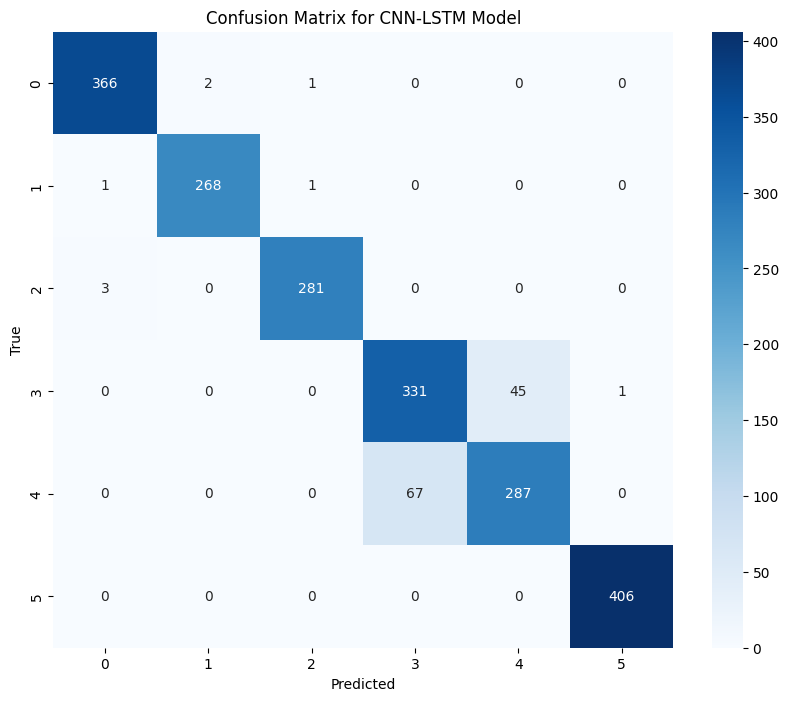

Accuracy: 0.9413
Precision: 0.9415
Recall: 0.9413
F1-score: 0.9411


In [5]:
# ทำนายผลลัพธ์จาก X_val ด้วยโมเดล CNN-LSTM ที่ดีที่สุด
y_pred_cnn_lstm = best_cnn_lstm_model.predict(X_val)
y_pred_cnn_lstm_classes = y_pred_cnn_lstm.argmax(axis=1)  # แปลงค่าที่ทำนายให้เป็น class

# สร้าง Confusion Matrix
y_true_classes = y_val.argmax(axis=1)  # แปลงค่าจริงให้เป็น class
cm_cnn_lstm = confusion_matrix(y_true_classes, y_pred_cnn_lstm_classes)

# แสดงผล Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn_lstm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for CNN-LSTM Model')
plt.show()

# คำนวณค่า Accuracy, Precision, Recall, และ F1-score
accuracy_cnn_lstm = accuracy_score(y_true_classes, y_pred_cnn_lstm_classes)
precision_cnn_lstm = precision_score(y_true_classes, y_pred_cnn_lstm_classes, average='weighted')
recall_cnn_lstm = recall_score(y_true_classes, y_pred_cnn_lstm_classes, average='weighted')
f1_cnn_lstm = f1_score(y_true_classes, y_pred_cnn_lstm_classes, average='weighted')

# แสดงผลค่า Accuracy, Precision, Recall, และ F1-score
print(f'Accuracy: {accuracy_cnn_lstm:.4f}')
print(f'Precision: {precision_cnn_lstm:.4f}')
print(f'Recall: {recall_cnn_lstm:.4f}')
print(f'F1-score: {f1_cnn_lstm:.4f}')